Accuracy test : 0.9600
CV 5-fold     : 0.9667 ± 0.0211

Reporte de clasificación:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        25
  versicolor       0.92      0.96      0.94        25
   virginica       0.96      0.92      0.94        25

    accuracy                           0.96        75
   macro avg       0.96      0.96      0.96        75
weighted avg       0.96      0.96      0.96        75



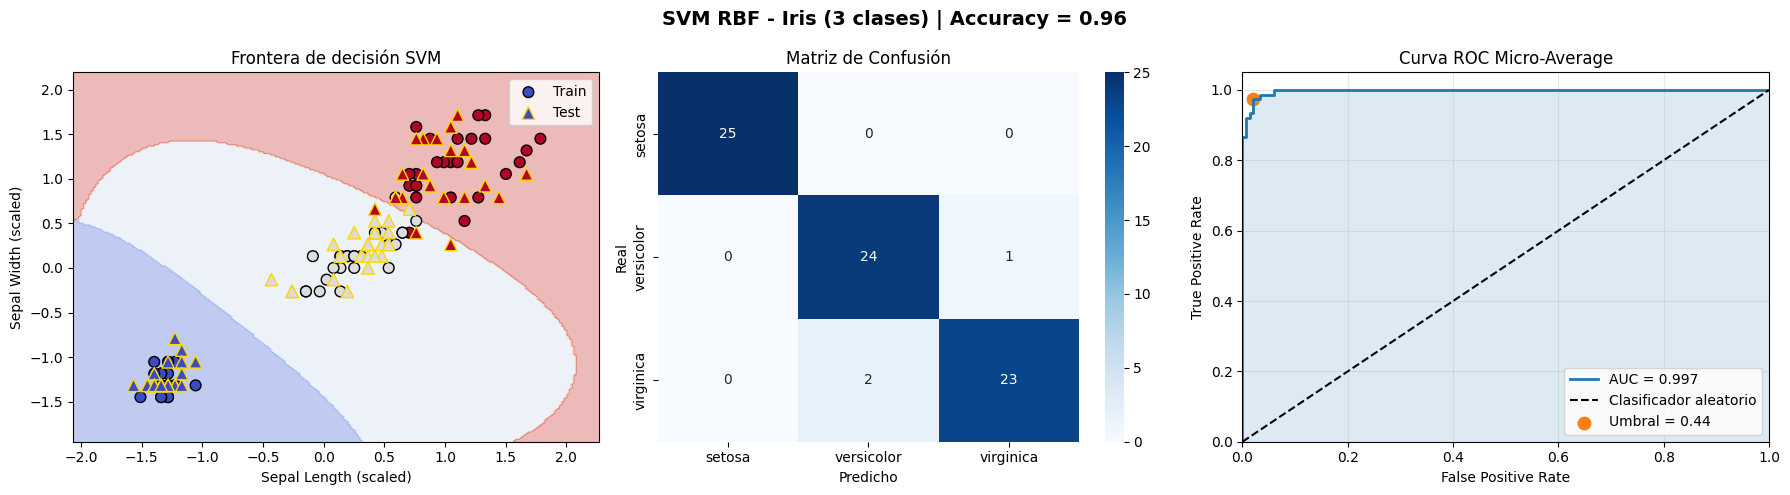

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm, datasets
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (
    roc_curve, auc,
    classification_report,
    confusion_matrix
)
from sklearn.multiclass import OneVsRestClassifier
import seaborn as sns

# ============================================================
# 1. Cargar datos
# ============================================================
iris = datasets.load_iris()

X = iris.data
y = iris.target
class_names = iris.target_names

# Para ROC multiclase
y_bin = label_binarize(y, classes=[0, 1, 2])

# ============================================================
# 2. Escalar datos
# ============================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ============================================================
# 3. Split para modelo completo (4 variables)
# ============================================================
(
    X_train,
    X_test,
    y_train,
    y_test,
    y_train_bin,
    y_test_bin
) = train_test_split(
    X_scaled,
    y,
    y_bin,
    test_size=0.5,
    random_state=42,
    stratify=y
)

# ============================================================
# 4. SVM completo (4 variables)
# ============================================================
clf = svm.SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True
)

clf.fit(X_train, y_train)

# ============================================================
# 5. ROC OvR
# ============================================================
clf_ovr = OneVsRestClassifier(
    svm.SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale',
        probability=True
    )
)

clf_ovr.fit(X_train, y_train_bin)

y_proba = clf_ovr.predict_proba(X_test)

# ============================================================
# 6. Métricas
# ============================================================
acc = clf.score(X_test, y_test)

cv_scores = cross_val_score(
    clf,
    X_scaled,
    y,
    cv=5
)

print(f"Accuracy test : {acc:.4f}")
print(f"CV 5-fold     : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

print("\nReporte de clasificación:")
print(
    classification_report(
        y_test,
        clf.predict(X_test),
        target_names=class_names
    )
)

# ============================================================
# 7. Modelo SOLO para visualización (2 variables)
# ============================================================
X_vis = X_scaled[:, 2:4]

X_train_vis, X_test_vis, y_train_vis, y_test_vis = train_test_split(
    X_vis,
    y,
    test_size=0.5,
    random_state=42,
    stratify=y
)

clf_vis = svm.SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale'
)

clf_vis.fit(X_train_vis, y_train_vis)

# ============================================================
# 8. Crear figura
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

fig.suptitle(
    f"SVM RBF - Iris (3 clases) | Accuracy = {acc:.2f}",
    fontsize=14,
    fontweight='bold'
)

# ============================================================
# 9. Frontera de decisión CORREGIDA
# ============================================================
ax = axes[0]

h = 0.02

x_min = X_vis[:, 0].min() - 0.5
x_max = X_vis[:, 0].max() + 0.5

y_min = X_vis[:, 1].min() - 0.5
y_max = X_vis[:, 1].max() + 0.5

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h)
)

grid = np.c_[xx.ravel(), yy.ravel()]

Z = clf_vis.predict(grid)
Z = Z.reshape(xx.shape)

ax.contourf(
    xx,
    yy,
    Z,
    cmap='coolwarm',
    alpha=0.35
)

ax.scatter(
    X_train_vis[:, 0],
    X_train_vis[:, 1],
    c=y_train_vis,
    cmap='coolwarm',
    edgecolors='black',
    s=60,
    label='Train'
)

ax.scatter(
    X_test_vis[:, 0],
    X_test_vis[:, 1],
    c=y_test_vis,
    cmap='coolwarm',
    edgecolors='gold',
    marker='^',
    s=80,
    label='Test'
)

ax.set_title("Frontera de decisión SVM")
ax.set_xlabel("Sepal Length (scaled)")
ax.set_ylabel("Sepal Width (scaled)")
ax.legend()

# ============================================================
# 10. Matriz de confusión
# ============================================================
ax = axes[1]

cm = confusion_matrix(
    y_test,
    clf.predict(X_test)
)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    ax=ax
)

ax.set_title("Matriz de Confusión")
ax.set_xlabel("Predicho")
ax.set_ylabel("Real")

# ============================================================
# 11. Curva ROC
# ============================================================
ax = axes[2]

fpr, tpr, thresholds = roc_curve(
    y_test_bin.ravel(),
    y_proba.ravel()
)

roc_auc = auc(fpr, tpr)

ax.plot(
    fpr,
    tpr,
    lw=2,
    label=f'AUC = {roc_auc:.3f}'
)

ax.fill_between(
    fpr,
    tpr,
    alpha=0.15
)

ax.plot(
    [0, 1],
    [0, 1],
    'k--',
    label='Clasificador aleatorio'
)

# Umbral óptimo (Índice de Youden)
youden = tpr - fpr
best_idx = np.argmax(youden)

ax.scatter(
    fpr[best_idx],
    tpr[best_idx],
    s=80,
    label=f'Umbral = {thresholds[best_idx]:.2f}'
)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")

ax.set_title("Curva ROC Micro-Average")
ax.legend(loc='lower right')
ax.grid(alpha=0.3)

# ============================================================
# 12. Mostrar
# ============================================================
plt.tight_layout()

plt.savefig(
    "svm_iris_3clases_corregido.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()